In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/sensor_data.csv")

df.head()

,time,temperature,vibration,pressure,failure_warning,failure
0,0,70.993428,20.348286,90.097140,0.0,0.0
1,1,69.723471,20.283324,94.725072,0.0,0.0
2,2,71.295377,19.063480,97.064858,0.0,0.0
3,3,73.046060,20.579584,100.748345,0.0,0.0
4,4,69.531693,18.509917,105.120812,0.0,0.0


In [8]:
df.shape

(10000, 6)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             10000 non-null  int64  
 1   temperature      10000 non-null  float64
 2   vibration        10000 non-null  float64
 3   pressure         10000 non-null  float64
 4   failure_warning  10000 non-null  float64
 5   failure          10000 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 468.9 KB


In [10]:
df.describe()

,time,temperature,vibration,pressure,failure_warning,failure
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000
mean,4999.50000,70.245728,20.137537,100.262143,0.080000,0.0001
std,2886.89568,2.853816,1.570052,5.572422,0.271307,0.0100
min,0.00000,62.155199,16.344913,77.671981,0.000000,0.0000
25%,2499.75000,68.686719,19.315953,96.587714,0.000000,0.0000
50%,4999.50000,70.039145,20.013075,100.068628,0.000000,0.0000
75%,7499.25000,71.418977,20.703655,103.589713,0.000000,0.0000
max,9999.00000,98.330285,36.840939,137.080866,1.000000,1.0000


In [11]:
df.isnull().sum()

time               0
temperature        0
vibration          0
pressure           0
failure_warning    0
failure            0
dtype: int64

In [12]:
df["failure_warning"].value_counts()

failure_warning
0.0    9200
1.0     800
Name: count, dtype: int64

In [13]:
df["failure_warning"].value_counts(normalize=True)

failure_warning
0.0    0.92
1.0    0.08
Name: proportion, dtype: float64

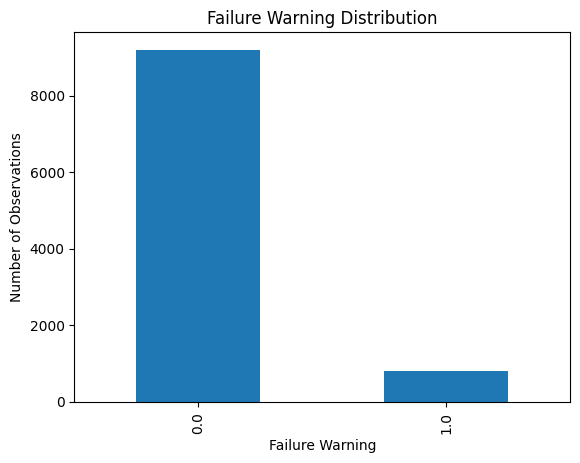

In [14]:
df["failure_warning"].value_counts().plot(kind="bar")

plt.title("Failure Warning Distribution")
plt.xlabel("Failure Warning")
plt.ylabel("Number of Observations")
plt.show()

In [15]:
df.groupby("failure_warning")[
    ["temperature", "vibration", "pressure"]
].mean()

,temperature,vibration,pressure
failure_warning,,,
0.0,69.992077,19.989953,99.962728
1.0,73.162719,21.834754,103.705409


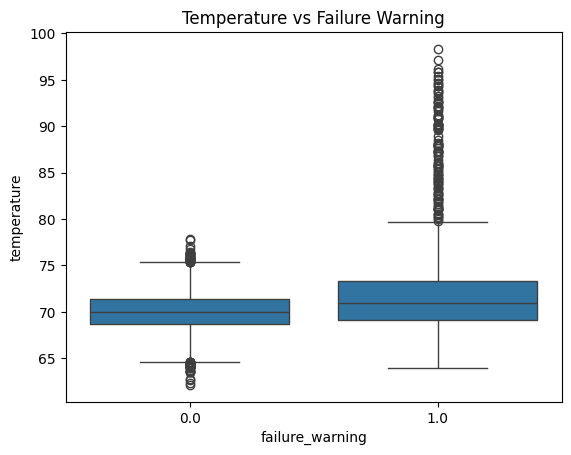

In [16]:
sns.boxplot(
    data=df,
    x="failure_warning",
    y="temperature"
)

plt.title("Temperature vs Failure Warning")
plt.show()

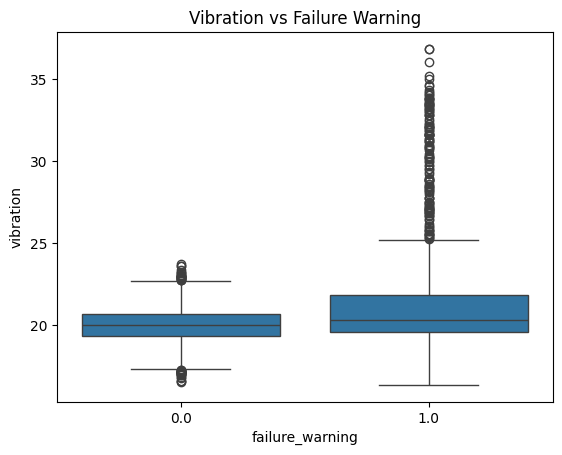

In [17]:
sns.boxplot(
    data=df,
    x="failure_warning",
    y="vibration"
)

plt.title("Vibration vs Failure Warning")
plt.show()

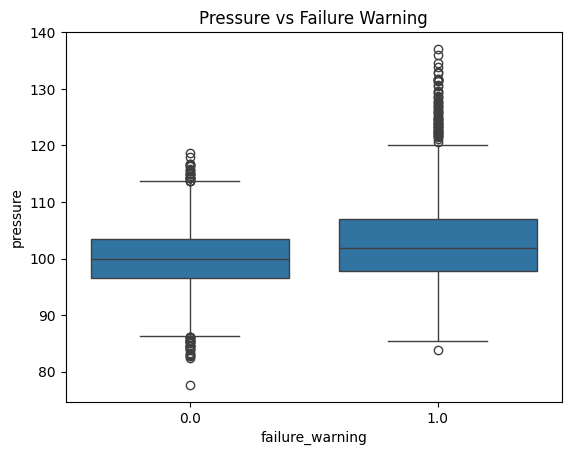

In [18]:
sns.boxplot(
    data=df,
    x="failure_warning",
    y="pressure"
)

plt.title("Pressure vs Failure Warning")
plt.show()

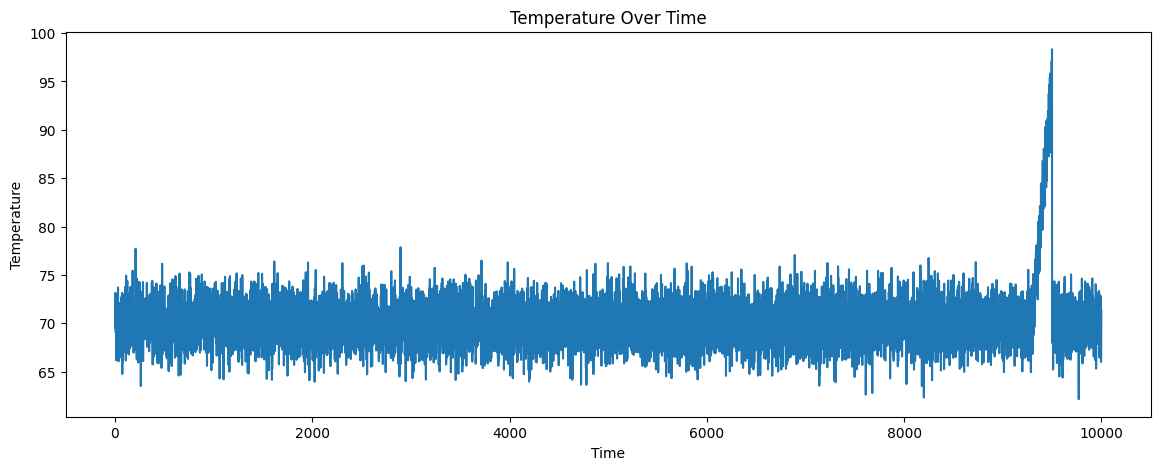

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(df["time"], df["temperature"])

plt.title("Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature")

plt.show()

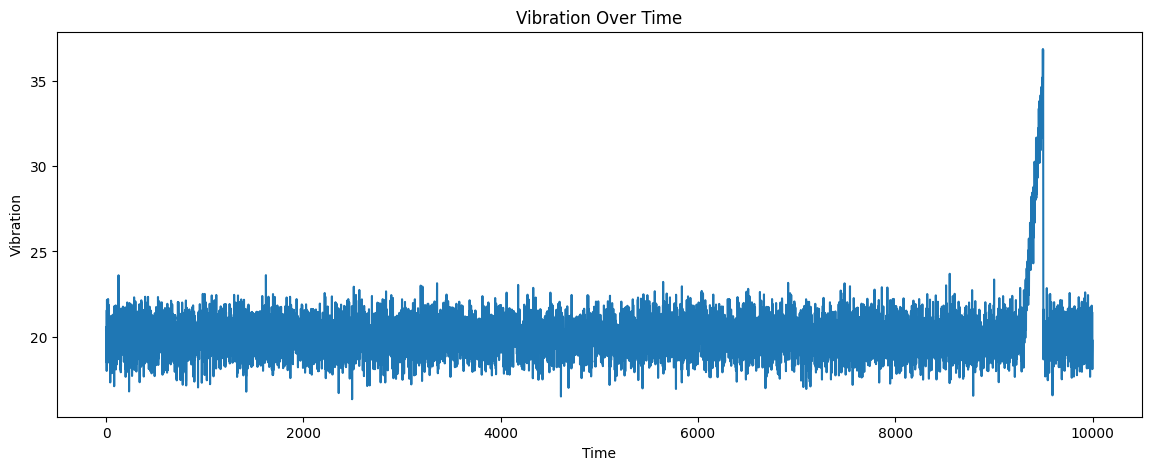

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(df["time"], df["vibration"])

plt.title("Vibration Over Time")
plt.xlabel("Time")
plt.ylabel("Vibration")

plt.show()

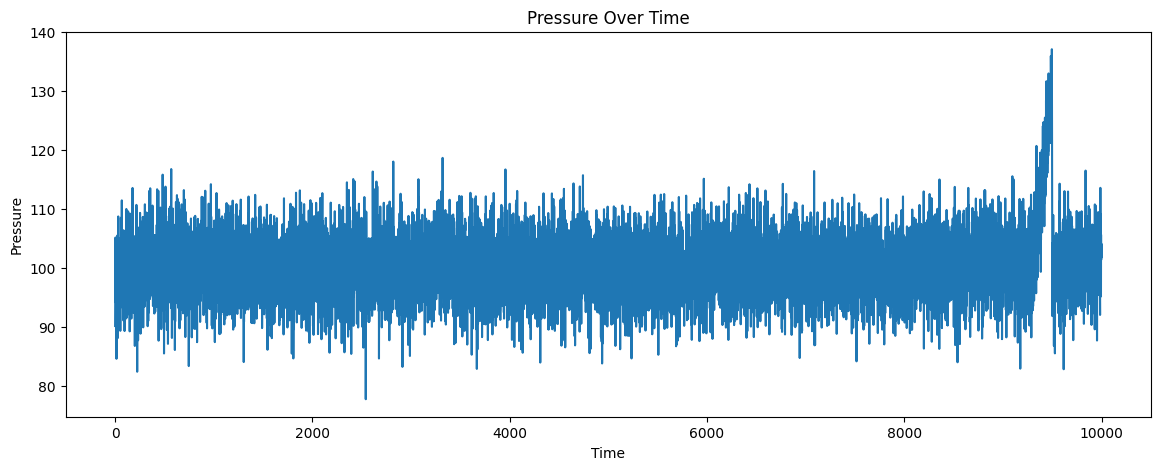

In [21]:
plt.figure(figsize=(14, 5))

plt.plot(df["time"], df["pressure"])

plt.title("Pressure Over Time")
plt.xlabel("Time")
plt.ylabel("Pressure")

plt.show()

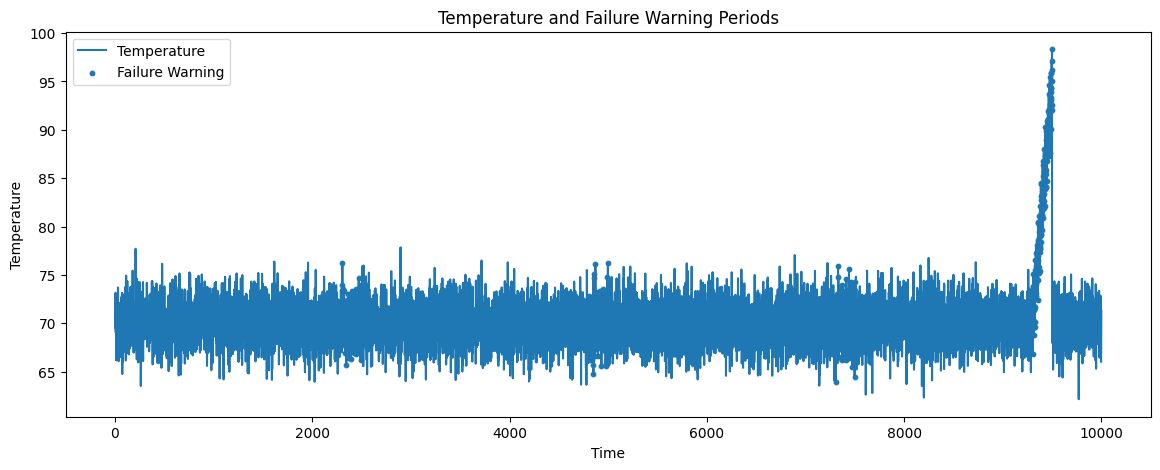

In [22]:
warning_data = df[df["failure_warning"] == 1]

plt.figure(figsize=(14, 5))

plt.plot(df["time"], df["temperature"], label="Temperature")

plt.scatter(
    warning_data["time"],
    warning_data["temperature"],
    s=10,
    label="Failure Warning"
)

plt.title("Temperature and Failure Warning Periods")
plt.xlabel("Time")
plt.ylabel("Temperature")

plt.legend()
plt.show()

In [23]:
window = 20

df["temperature_mean_20"] = (
    df["temperature"]
    .rolling(window)
    .mean()
)

df["vibration_mean_20"] = (
    df["vibration"]
    .rolling(window)
    .mean()
)

df["pressure_mean_20"] = (
    df["pressure"]
    .rolling(window)
    .mean()
)

In [24]:
df["temperature_std_20"] = (
    df["temperature"]
    .rolling(window)
    .std()
)

df["vibration_std_20"] = (
    df["vibration"]
    .rolling(window)
    .std()
)

df["pressure_std_20"] = (
    df["pressure"]
    .rolling(window)
    .std()
)

In [25]:
df = df.dropna().reset_index(drop=True)

In [26]:
df.head()

,time,temperature,vibration,pressure,failure_warning,failure,temperature_mean_20,vibration_mean_20,pressure_mean_20,temperature_std_20,vibration_std_20,pressure_std_20
0,19,67.175393,21.820967,97.281535,0.0,0.0,69.657403,19.885067,97.469400,1.920057,1.166766,5.248320
1,20,72.931298,22.213278,105.002742,0.0,0.0,69.754296,19.978317,98.214680,2.036398,1.275222,5.204475
2,21,69.548447,20.204989,103.715987,0.0,0.0,69.745545,19.974400,98.664226,2.036913,1.274356,5.275015
3,22,70.135056,20.148943,98.455193,0.0,0.0,69.687529,20.028673,98.733743,2.006748,1.256508,5.261973
4,23,67.150504,19.663680,97.891202,0.0,0.0,69.392751,19.982878,98.590886,1.918506,1.252055,5.243151
